<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES19Sim001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# === Core HES kernel (stable, boundary-aware) ===
import numpy as np

# Hyperparameters (tunable, with safe defaults)
dt = 0.01      # explicit step size
γ  = 0.1       # sequestration strength
alpha = 0.1    # Laplacian smoothing
clip = 5.0     # soft amplitude cap

def periodic_gradient_1d(S):
    # central difference with wrap-around
    return 0.5 * ((np.roll(S, -1) - S) - (S - np.roll(S, 1)))

def periodic_laplacian_1d(S):
    return np.roll(S, -1) - 2.0 * S + np.roll(S, 1)

def entropic_gradient_1d(S):
    g = periodic_gradient_1d(S)
    n = np.linalg.norm(g) + 1e-12
    return g / n

def holographic_sequestration(S):
    # mean-centering: penalize deviations from global frame
    return S - np.mean(S)

def HES_update_1d(S, λ, N):
    dS = λ * entropic_gradient_1d(S) + alpha * periodic_laplacian_1d(S) - (γ / N) * holographic_sequestration(S)
    S_next = S + dt * dS
    # soft squash to prevent blow-up while preserving dynamics
    return np.tanh(S_next / clip) * clip

def simulate_1d(L, λ, N, steps, init_scale=0.1):
    S = np.random.randn(L) * init_scale
    traj_var = []
    for t in range(steps):
        S = HES_update_1d(S, λ, N)
        if not np.isfinite(S).all():
            return np.array(traj_var), S, False
        traj_var.append(np.var(S))
    return np.array(traj_var), S, True

# Helpers
def rfft_modes(S):
    # return real-valued magnitudes of Fourier modes (excluding DC)
    F = np.fft.rfft(S)
    mags = np.abs(F)
    return mags[1:]  # drop k=0


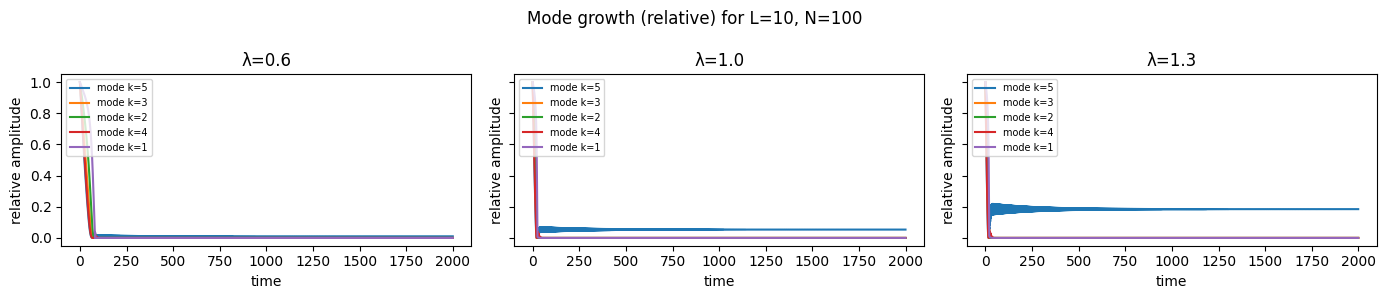

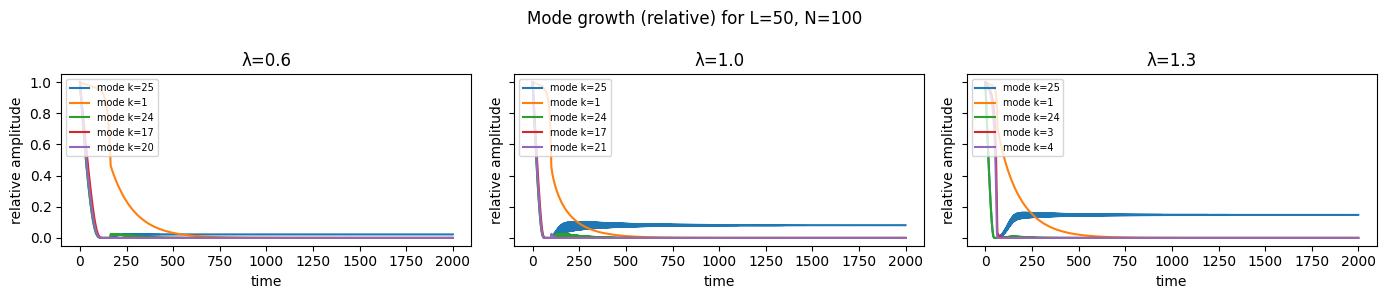

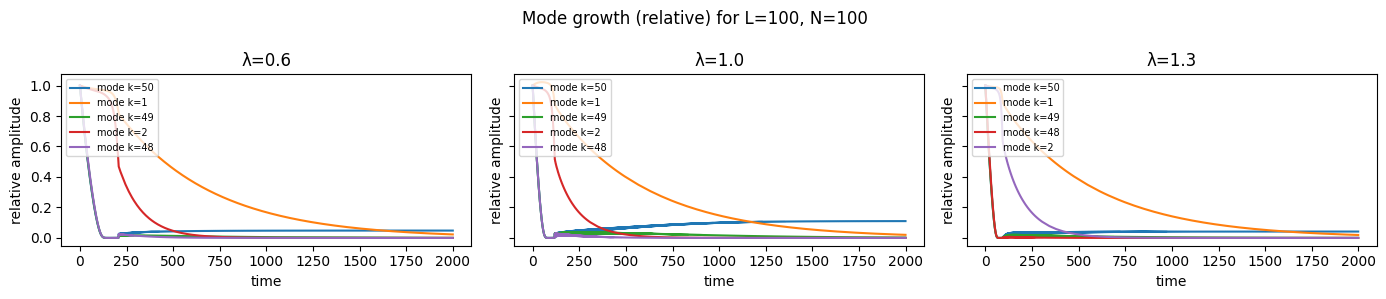

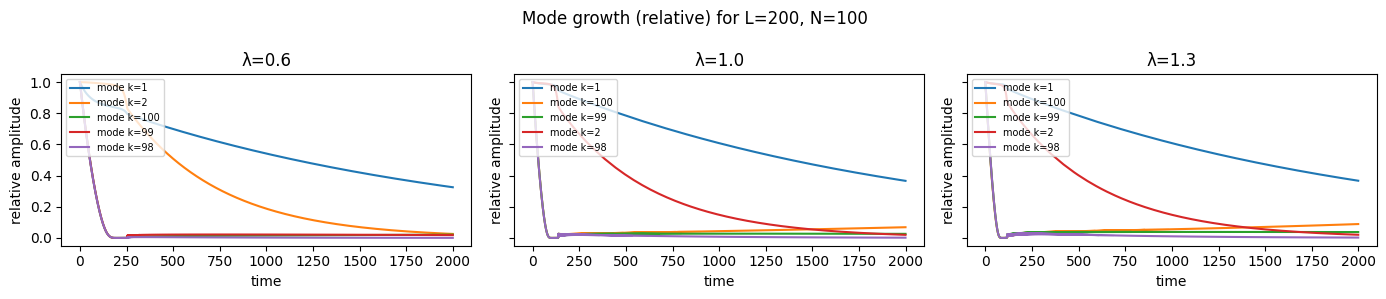

L=10, λ=0.6: dominant modes (k) = [5, 4, 1, 3, 2]
L=10, λ=1.0: dominant modes (k) = [5, 4, 3, 2, 1]
L=10, λ=1.3: dominant modes (k) = [5, 3, 2, 4, 1]
L=50, λ=0.6: dominant modes (k) = [25, 1, 24, 3, 10]
L=50, λ=1.0: dominant modes (k) = [25, 24, 1, 11, 4]
L=50, λ=1.3: dominant modes (k) = [25, 1, 24, 22, 18]
L=100, λ=0.6: dominant modes (k) = [50, 1, 49, 2, 48]
L=100, λ=1.0: dominant modes (k) = [50, 1, 49, 2, 48]
L=100, λ=1.3: dominant modes (k) = [50, 1, 49, 2, 48]
L=200, λ=0.6: dominant modes (k) = [1, 99, 2, 100, 98]
L=200, λ=1.0: dominant modes (k) = [1, 100, 2, 99, 98]
L=200, λ=1.3: dominant modes (k) = [1, 100, 2, 99, 98]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100
steps = 2000
L_values = [10, 50, 100, 200]
lambda_tests = [0.6, 1.0, 1.3]  # adjust per your observed peaks/valleys

def analyze_mode_growth(L, λ, N, steps):
    S = np.random.randn(L) * 0.1
    # track mode magnitudes over time
    growth = []
    for t in range(steps):
        S = HES_update_1d(S, λ, N)
        mags = rfft_modes(S)  # length ~ L//2
        growth.append(mags)
    G = np.array(growth)  # [time, mode]
    # relative growth vs initial
    rel = G / (G[0] + 1e-12)
    # dominant modes by final amplification
    final = rel[-1]
    dom_idx = np.argsort(final)[-5:][::-1]
    return rel, dom_idx, final

# Run tracker and visualize dominant modes
for L in L_values:
    fig, axes = plt.subplots(1, len(lambda_tests), figsize=(14, 3), sharey=True)
    fig.suptitle(f"Mode growth (relative) for L={L}, N=100")
    for j, λ in enumerate(lambda_tests):
        rel, dom_idx, final = analyze_mode_growth(L, λ, N, steps)
        ax = axes[j]
        for k in dom_idx:
            ax.plot(rel[:, k], label=f"mode k={k+1}")
        ax.set_title(f"λ={λ}")
        ax.set_xlabel("time")
        ax.set_ylabel("relative amplitude")
        ax.legend(loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()

# Print dominant modes summary
for L in L_values:
    for λ in lambda_tests:
        rel, dom_idx, final = analyze_mode_growth(L, λ, N, steps)
        print(f"L={L}, λ={λ}: dominant modes (k) =", [int(k+1) for k in dom_idx])


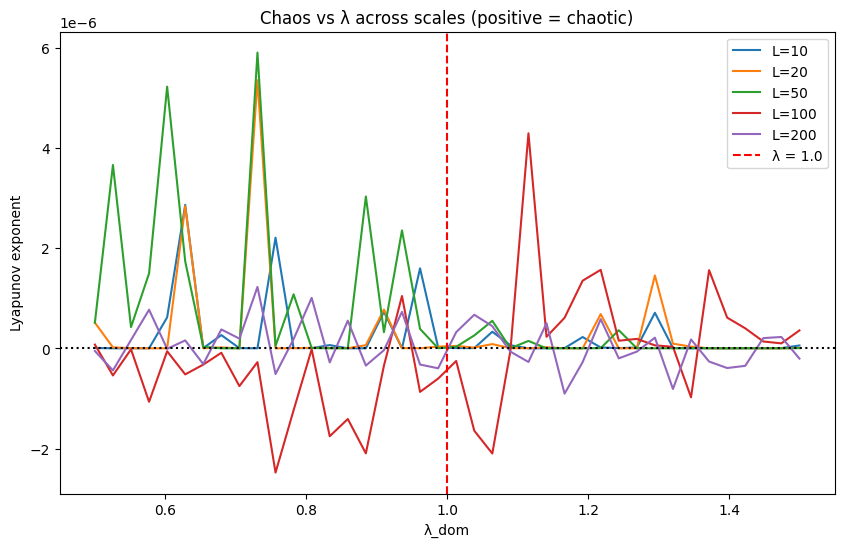

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def lyapunov_exponent_1d(L, λ, N, steps, eps=1e-6, init_scale=0.1):
    S1 = np.random.randn(L) * init_scale
    S2 = S1 + eps * np.random.randn(L)
    logs = []
    for t in range(steps):
        S1 = HES_update_1d(S1, λ, N)
        S2 = HES_update_1d(S2, λ, N)
        d = S2 - S1
        dist = np.linalg.norm(d) + 1e-12
        logs.append(np.log(dist))
        # renormalize to keep separation small
        S2 = S1 + eps * d / dist
    # slope over second half to avoid transients
    T = len(logs)
    if T < 4:
        return np.nan
    x = np.arange(T//2, T)
    y = np.array(logs[T//2:])
    # simple linear fit for slope
    A = np.vstack([x, np.ones_like(x)]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]
    return m  # positive => chaotic; negative => stable

# Sweep across λ and L
lambda_values = np.linspace(0.5, 1.5, 40)
L_values = [10, 20, 50, 100, 200]
N = 100
steps = 1500

lyap_map = {L: [lyapunov_exponent_1d(L, λ, N, steps) for λ in lambda_values] for L in L_values}

plt.figure(figsize=(10,6))
for L in L_values:
    plt.plot(lambda_values, lyap_map[L], label=f"L={L}")
plt.axhline(0, color='black', linestyle=':')
plt.axvline(1.0, color='red', linestyle='--', label="λ = 1.0")
plt.xlabel("λ_dom")
plt.ylabel("Lyapunov exponent")
plt.title("Chaos vs λ across scales (positive = chaotic)")
plt.legend()
plt.show()


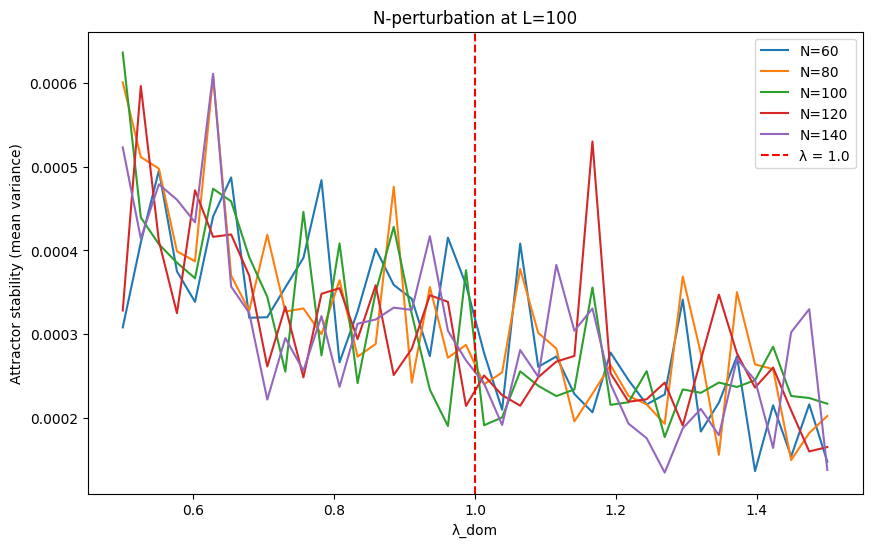

Void(L=10, λ=1.0): stable
Void(L=100, λ=1.0): stable
Void(L=100, λ=0.6): stable
Void(L=200, λ=1.3): stable


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Stability metric: mean variance over trajectory
def stability_metric(L, λ, N, steps=1500):
    traj_var, S, ok = simulate_1d(L, λ, N, steps)
    return np.nan if not ok or len(traj_var) == 0 else float(np.mean(traj_var))

# N sweep at fixed L, compare around N=100
L_fixed = 100
N_values = [60, 80, 100, 120, 140]
lambda_values = np.linspace(0.5, 1.5, 40)

plt.figure(figsize=(10,6))
for N in N_values:
    curve = [stability_metric(L_fixed, λ, N) for λ in lambda_values]
    plt.plot(lambda_values, curve, label=f"N={N}")
plt.axvline(1.0, color='red', linestyle='--', label="λ = 1.0")
plt.xlabel("λ_dom")
plt.ylabel("Attractor stability (mean variance)")
plt.title(f"N-perturbation at L={L_fixed}")
plt.legend()
plt.show()

# Void stability constraint (operational)
def resonant_bands_from_modes(L, λ_grid, N, steps=800, amp_thresh=3.0):
    # Detect λ where dominant mode amplification exceeds threshold
    bands = []
    for λ in λ_grid:
        rel, dom_idx, final = analyze_mode_growth(L, λ, N, steps)
        if np.max(final) > amp_thresh:
            bands.append(λ)
    return np.array(bands)

def void_stability_constraint(L_void, λ_void, N=100, tol=0.05):
    λ_grid = np.linspace(max(0.1, λ_void-0.2), λ_void+0.2, 60)
    bands = resonant_bands_from_modes(L_void, λ_grid, N)
    if len(bands) == 0:
        return True
    return np.all(np.abs(bands - λ_void) > tol)

# Example: check candidate voids
candidates = [(10, 1.0), (100, 1.0), (100, 0.6), (200, 1.3)]
for (L_void, λ_void) in candidates:
    ok = void_stability_constraint(L_void, λ_void)
    print(f"Void(L={L_void}, λ={λ_void}): {'stable' if ok else 'resonant/unstable'}")


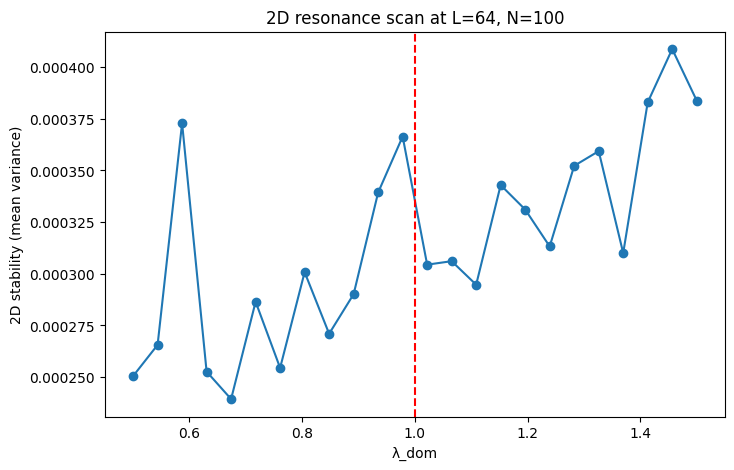

In [ ]:
import numpy as np

# 2D kernel (periodic)
def grad2d(S):
    gx = 0.5 * ((np.roll(S, -1, axis=0) - S) - (S - np.roll(S, 1, axis=0)))
    gy = 0.5 * ((np.roll(S, -1, axis=1) - S) - (S - np.roll(S, 1, axis=1)))
    gmag = np.sqrt(gx**2 + gy**2) + 1e-12
    return (gx + gy) / gmag  # normalized combined direction

def laplacian2d(S):
    return (np.roll(S, -1, axis=0) + np.roll(S, 1, axis=0) +
            np.roll(S, -1, axis=1) + np.roll(S, 1, axis=1) - 4.0 * S)

def HES_update_2d(S, λ, N):
    dS = λ * grad2d(S) + alpha * laplacian2d(S) - (γ / N) * (S - np.mean(S))
    S_next = S + dt * dS
    return np.tanh(S_next / clip) * clip

def simulate_2d(L, λ, N, steps, init_scale=0.1):
    S = np.random.randn(L, L) * init_scale
    traj_var = []
    for t in range(steps):
        S = HES_update_2d(S, λ, N)
        if not np.isfinite(S).all():
            return np.array(traj_var), S, False
        traj_var.append(np.var(S))
    return np.array(traj_var), S, True

# Quick scan for resonance surface signature
L2 = 64
lambda_values = np.linspace(0.5, 1.5, 24)
stability_2d = [np.mean(simulate_2d(L2, λ, 100, 800)[0]) for λ in lambda_values]
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(lambda_values, stability_2d, '-o')
plt.axvline(1.0, color='red', linestyle='--')
plt.xlabel("λ_dom")
plt.ylabel("2D stability (mean variance)")
plt.title(f"2D resonance scan at L={L2}, N=100")
plt.show()
